# Customer Analysis

This notebook analyzes customer behavior for the online retail business.

The goal is to understand how customers contribute to revenue, how often they return, which customers are the most valuable, and whether the business depends on a small group of high-value customers.

## Questions (possible)
1. How many customers made purchases during the analyzed period?
2. How many customers made repeat purchases?
3. What is the repeat purchase rate?
4. How much revenue does an average customer generate?
5. Which customers generate the most revenue?
6. Is revenue concentrated among a small group of customers?
7. How does the customer base change over time?
8. What business actions can improve customer retention and revenue?

## 1. Imports and Data Loading

I use two prepared datasets:

- `online_retail_clean.csv` — cleaned transaction-level data.
- `orders.csv` — order-level table aggregated by `invoice_no`.

The order-level table is more convenient for customer behavior analysis because customer frequency should usually be counted by orders, not by individual product lines.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

clean_path = ROOT_DIR / "data" / "processed" / "online_retail_clean.csv"
orders_path = ROOT_DIR / "data" / "processed" / "orders.csv"

df = pd.read_csv(clean_path, parse_dates=["invoice_date"])
orders = pd.read_csv(orders_path, parse_dates=["invoice_date"])

df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancelled,line_revenue,invoice_day,invoice_month,invoice_year,invoice_hour,day_of_week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30,2010-12-01,2010-12,2010,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01,2010-12,2010,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00,2010-12-01,2010-12,2010,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01,2010-12,2010,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01,2010-12,2010,8,Wednesday


In [3]:
orders.head()

,invoice_no,customer_id,country,invoice_date,invoice_month,total_quantity,order_revenue,unique_products
0,536365,17850,United Kingdom,2010-12-01 08:26:00,2010-12,40,139.12,7
1,536366,17850,United Kingdom,2010-12-01 08:28:00,2010-12,12,22.20,2
2,536367,13047,United Kingdom,2010-12-01 08:34:00,2010-12,83,278.73,12
3,536368,13047,United Kingdom,2010-12-01 08:34:00,2010-12,15,70.05,4
4,536369,13047,United Kingdom,2010-12-01 08:35:00,2010-12,3,17.85,1


## 2. Customer-Level Dataset

To analyze customers, need aggregate orders by `customer_id`.

For each customer calculate:

- total number of orders;
- total revenue;
- average order value;
- first purchase date;
- last purchase date;
- customer lifetime in days;
- number of active purchase months;
- number of countries associated with the customer's orders.

In [4]:
customer_metrics = (
    orders
    .groupby("customer_id", as_index=False)
    .agg(
        orders=("invoice_no", "nunique"),
        total_revenue=("order_revenue", "sum"),
        avg_order_value=("order_revenue", "mean"),
        first_purchase=("invoice_date", "min"),
        last_purchase=("invoice_date", "max"),
        active_months=("invoice_month", "nunique"),
        countries=("country", "nunique"),
    )
)

customer_metrics["customer_lifetime_days"] = (
    customer_metrics["last_purchase"] - customer_metrics["first_purchase"]
).dt.days

customer_metrics["is_repeat_customer"] = customer_metrics["orders"] > 1

customer_metrics.head()

,customer_id,orders,total_revenue,avg_order_value,first_purchase,last_purchase,active_months,countries,customer_lifetime_days,is_repeat_customer
0,12346,1,"77,183.60","77,183.60",2011-01-18 10:01:00,2011-01-18 10:01:00,1,1,0,False
1,12347,7,"4,310.00",615.71,2010-12-07 14:57:00,2011-12-07 15:52:00,7,1,365,True
2,12348,4,"1,797.24",449.31,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1,282,True
3,12349,1,"1,757.55","1,757.55",2011-11-21 09:51:00,2011-11-21 09:51:00,1,1,0,False
4,12350,1,334.40,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,1,1,0,False


## 3. Customer KPI Overview
metrics:

- **Total customers** — number of unique customers.
- **Repeat customers** — customers with more than one order.
- **Repeat purchase rate** — share of customers who made more than one order.
- **Revenue per customer** — average revenue generated by one customer.
- **Orders per customer** — average number of orders per customer.

In [5]:
total_customers = customer_metrics["customer_id"].nunique()
repeat_customers = customer_metrics["is_repeat_customer"].sum()
one_time_customers = total_customers - repeat_customers

repeat_purchase_rate = repeat_customers / total_customers
total_revenue = customer_metrics["total_revenue"].sum()
revenue_per_customer = total_revenue / total_customers
orders_per_customer = customer_metrics["orders"].mean()
median_orders_per_customer = customer_metrics["orders"].median()
median_revenue_per_customer = customer_metrics["total_revenue"].median()

customer_kpi = pd.DataFrame(
    {
        "metric": [
            "Total customers",
            "One-time customers",
            "Repeat customers",
            "Repeat purchase rate",
            "Total revenue",
            "Average revenue per customer",
            "Median revenue per customer",
            "Average orders per customer",
            "Median orders per customer",
        ],
        "value": [
            total_customers,
            one_time_customers,
            repeat_customers,
            repeat_purchase_rate,
            total_revenue,
            revenue_per_customer,
            median_revenue_per_customer,
            orders_per_customer,
            median_orders_per_customer,
        ],
    }
)

customer_kpi

,metric,value
0,Total customers,"4,338.00"
1,One-time customers,"1,493.00"
2,Repeat customers,"2,845.00"
3,Repeat purchase rate,0.66
4,Total revenue,"8,911,407.90"
5,Average revenue per customer,"2,054.27"
6,Median revenue per customer,674.49
7,Average orders per customer,4.27
8,Median orders per customer,2.00


The repeat purchase rate is one of the most important customer metrics in this project.

## 4. One-Time vs Repeat Customers

In [6]:
customer_type_summary = (
    customer_metrics
    .groupby("is_repeat_customer", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("total_revenue", "sum"),
        avg_revenue_per_customer=("total_revenue", "mean"),
        avg_orders_per_customer=("orders", "mean"),
    )
)

customer_type_summary["customer_share"] = (
    customer_type_summary["customers"] / customer_type_summary["customers"].sum()
)

customer_type_summary["revenue_share"] = (
    customer_type_summary["revenue"] / customer_type_summary["revenue"].sum()
)

customer_type_summary["customer_type"] = np.where(
    customer_type_summary["is_repeat_customer"],
    "Repeat customers",
    "One-time customers",
)

customer_type_summary = customer_type_summary[
    [
        "customer_type",
        "customers",
        "customer_share",
        "revenue",
        "revenue_share",
        "avg_revenue_per_customer",
        "avg_orders_per_customer",
    ]
]

customer_type_summary

,customer_type,customers,customer_share,revenue,revenue_share,avg_revenue_per_customer,avg_orders_per_customer
0,One-time customers,1493,0.34,"616,311.73",0.07,412.80,1.00
1,Repeat customers,2845,0.66,"8,295,096.17",0.93,"2,915.68",5.99


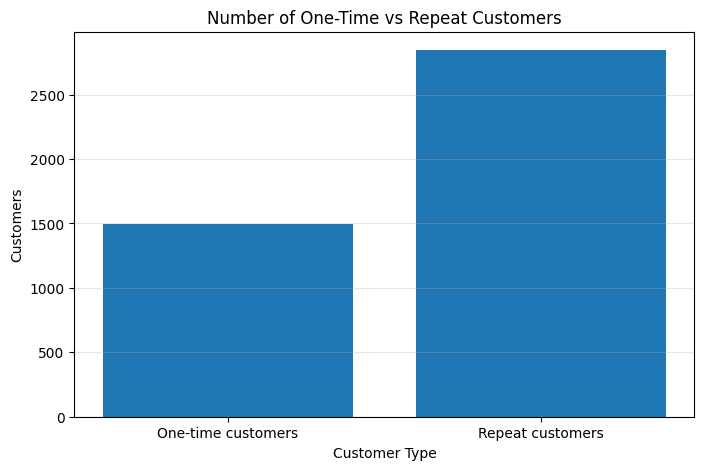

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(customer_type_summary["customer_type"], customer_type_summary["customers"])
plt.title("Number of One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

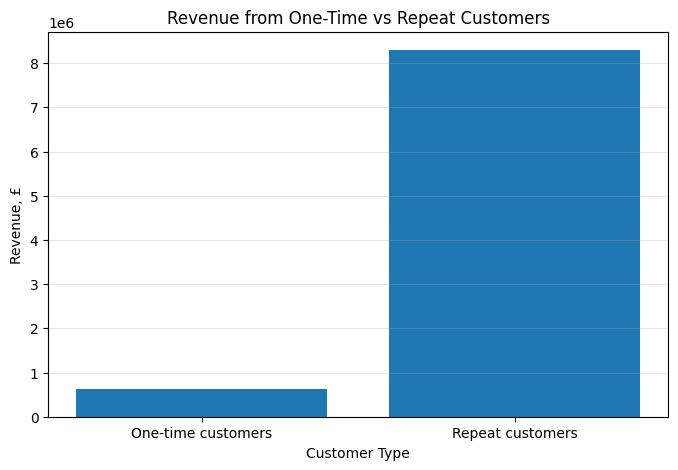

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(customer_type_summary["customer_type"], customer_type_summary["revenue"])
plt.title("Revenue from One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Revenue, £")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 5. Distribution of Orders per Customer

In [9]:
orders_distribution = (
    customer_metrics
    .groupby("orders", as_index=False)
    .agg(customers=("customer_id", "nunique"))
    .sort_values("orders")
)

orders_distribution.head(20)

,orders,customers
0,1,1493
1,2,835
2,3,508
3,4,388
4,5,242
5,6,172
6,7,143
7,8,98
8,9,68
9,10,54


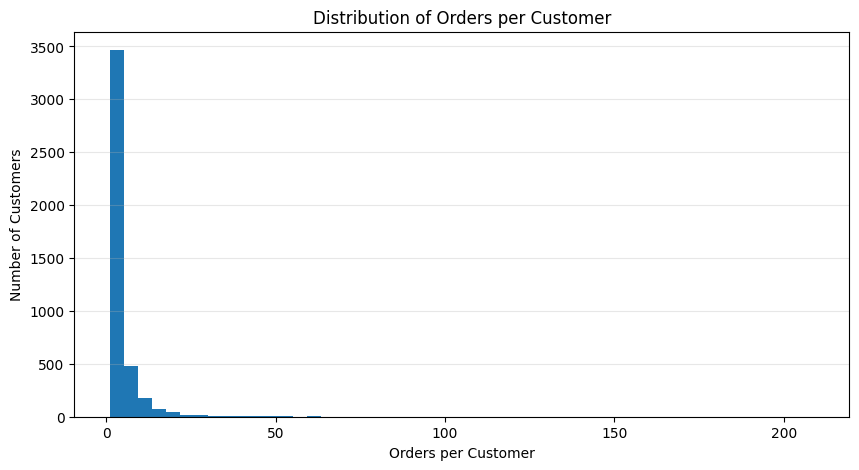

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(customer_metrics["orders"], bins=50)
plt.title("Distribution of Orders per Customer")
plt.xlabel("Orders per Customer")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

The histogram can be skewed because a few customers may have very high order counts.  
To better see the main customer base, we can limit the x-axis to customers with up to 20 orders.

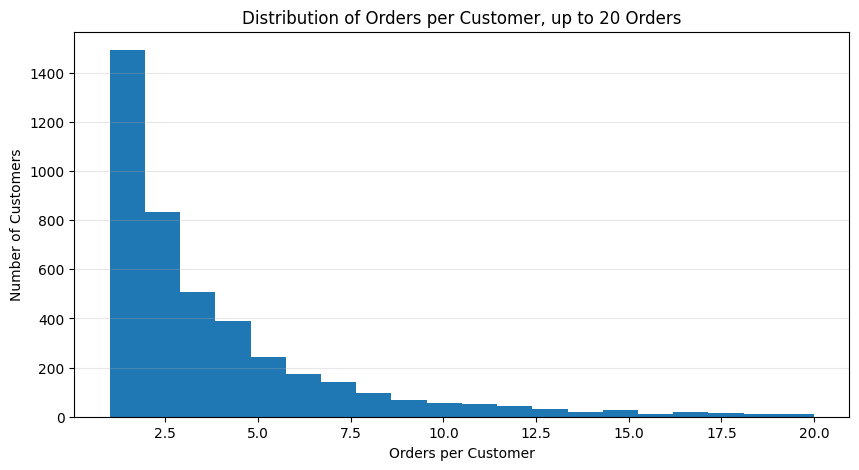

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(customer_metrics.loc[customer_metrics["orders"] <= 20, "orders"], bins=20)
plt.title("Distribution of Orders per Customer, up to 20 Orders")
plt.xlabel("Orders per Customer")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 6. Distribution of Revenue per Customer

Revenue per customer is usually highly skewed: most customers generate relatively small revenue, while a small group of customers contributes a large share of total revenue

In [13]:
customer_metrics["total_revenue"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count     4,338.00
mean      2,054.27
std       8,989.23
min           3.75
25%         307.41
50%         674.49
75%       1,661.74
90%       3,646.53
95%       5,841.84
99%      19,881.00
max     280,206.02
Name: total_revenue, dtype: float64

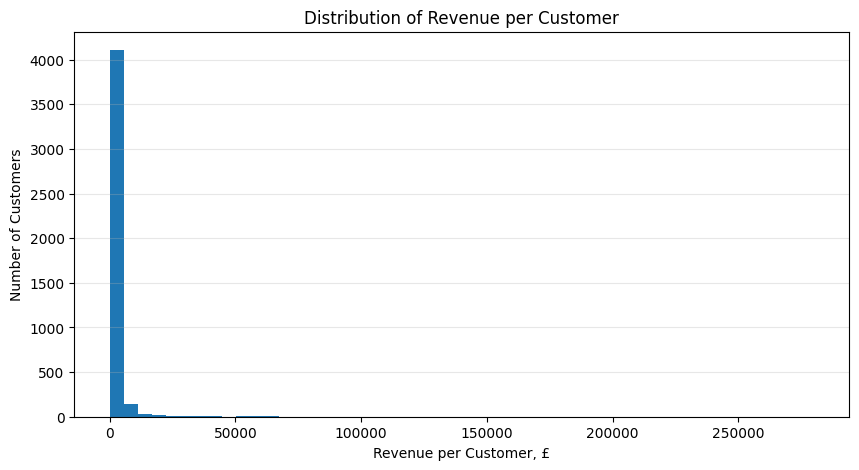

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(customer_metrics["total_revenue"], bins=50)
plt.title("Distribution of Revenue per Customer")
plt.xlabel("Revenue per Customer, £")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

The full distribution may be difficult to interpret because of high-value outliers.  
A clipped view up to the 95th percentile helps show the typical customer behavior.

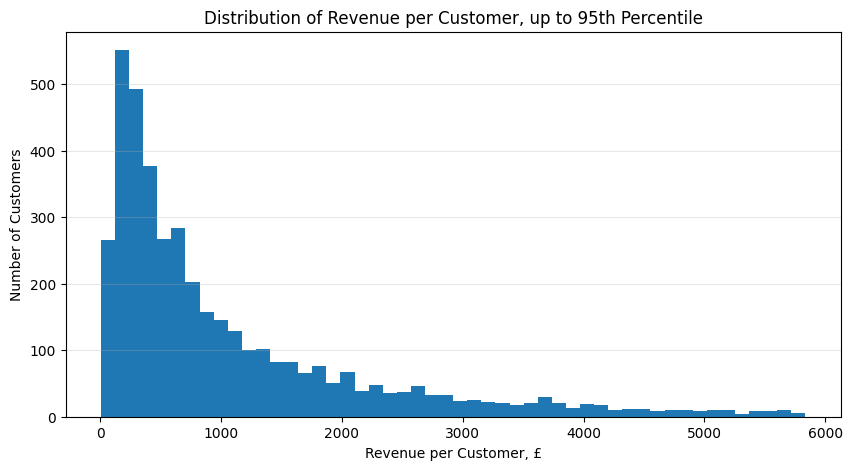

95th percentile revenue per customer: £5,841.84


In [15]:
p95_revenue = customer_metrics["total_revenue"].quantile(0.95)

plt.figure(figsize=(10, 5))
plt.hist(customer_metrics.loc[customer_metrics["total_revenue"] <= p95_revenue, "total_revenue"], bins=50)
plt.title("Distribution of Revenue per Customer, up to 95th Percentile")
plt.xlabel("Revenue per Customer, £")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

print(f"95th percentile revenue per customer: £{p95_revenue:,.2f}")

## 7. Top Customers by Revenue

In [12]:
top_customers = (
    customer_metrics
    .sort_values("total_revenue", ascending=False)
    .head(20)
)

top_customers

,customer_id,orders,total_revenue,avg_order_value,first_purchase,last_purchase,active_months,countries,customer_lifetime_days,is_repeat_customer
1689,14646,73,"280,206.02","3,838.44",2010-12-20 10:09:00,2011-12-08 12:12:00,13,1,353,True
4201,18102,60,"259,657.30","4,327.62",2010-12-07 16:42:00,2011-12-09 11:50:00,12,1,366,True
3728,17450,46,"194,550.79","4,229.36",2010-12-07 09:23:00,2011-12-01 13:29:00,12,1,359,True
3008,16446,2,"168,472.50","84,236.25",2011-05-18 09:52:00,2011-12-09 09:15:00,2,1,204,True
1879,14911,201,"143,825.06",715.55,2010-12-01 14:05:00,2011-12-08 15:54:00,13,1,372,True
55,12415,21,"124,914.53","5,948.31",2011-01-06 11:12:00,2011-11-15 14:22:00,11,1,313,True
1333,14156,55,"117,379.63","2,134.18",2010-12-03 11:48:00,2011-11-30 10:54:00,12,1,361,True
3771,17511,31,"91,062.38","2,937.50",2010-12-01 10:19:00,2011-12-07 10:12:00,13,1,370,True
2702,16029,63,"81,024.84","1,286.11",2010-12-01 09:57:00,2011-11-01 10:27:00,12,1,335,True
0,12346,1,"77,183.60","77,183.60",2011-01-18 10:01:00,2011-01-18 10:01:00,1,1,0,False


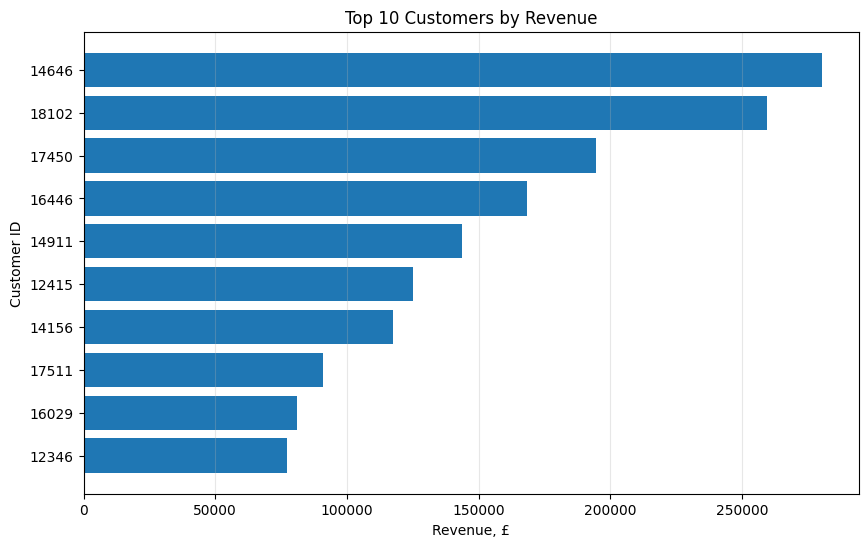

In [13]:
top_customers_plot = top_customers.head(10).sort_values("total_revenue")

plt.figure(figsize=(10, 6))
plt.barh(top_customers_plot["customer_id"].astype(str), top_customers_plot["total_revenue"])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue, £")
plt.ylabel("Customer ID")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 8. Customer Revenue Concentration

This section checks how much revenue is generated by the top customer groups.

I calculate revenue share for:

- top 1% customers;
- top 5% customers;
- top 10% customers;
- top 20% customers.

This is like Pareto analysis

In [18]:
customer_metrics_sorted = customer_metrics.sort_values("total_revenue", ascending=False).copy()
customer_metrics_sorted["customer_rank"] = np.arange(1, len(customer_metrics_sorted) + 1)
customer_metrics_sorted["customer_percentile_rank"] = (
    customer_metrics_sorted["customer_rank"] / len(customer_metrics_sorted)
)
customer_metrics_sorted["cumulative_revenue"] = customer_metrics_sorted["total_revenue"].cumsum()
customer_metrics_sorted["cumulative_revenue_share"] = (
    customer_metrics_sorted["cumulative_revenue"] / customer_metrics_sorted["total_revenue"].sum()
)

def top_customer_share(percent: float) -> float:
    n = max(1, int(np.ceil(len(customer_metrics_sorted) * percent)))
    return customer_metrics_sorted.head(n)["total_revenue"].sum() / customer_metrics_sorted["total_revenue"].sum()

concentration = pd.DataFrame(
    {
        "customer_group": ["Top 1%", "Top 5%", "Top 10%", "Top 20%"],
        "revenue_share": [
            top_customer_share(0.01),
            top_customer_share(0.05),
            top_customer_share(0.10),
            top_customer_share(0.20),
        ],
    }
)

concentration

,customer_group,revenue_share
0,Top 1%,0.32
1,Top 5%,0.50
2,Top 10%,0.61
3,Top 20%,0.75


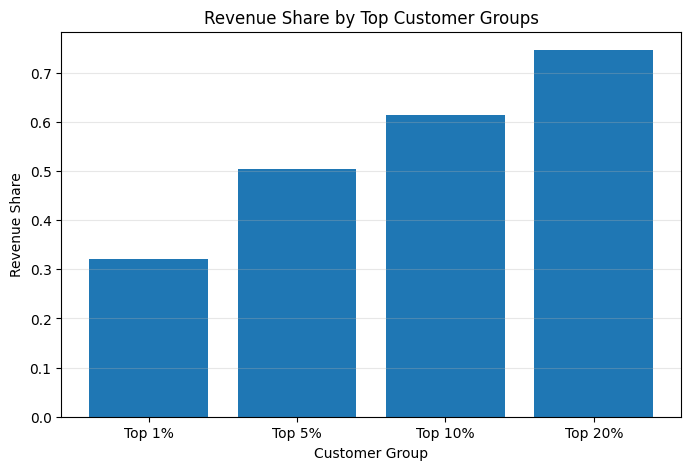

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(concentration["customer_group"], concentration["revenue_share"])
plt.title("Revenue Share by Top Customer Groups")
plt.xlabel("Customer Group")
plt.ylabel("Revenue Share")
plt.grid(axis="y", alpha=0.3)
plt.show()

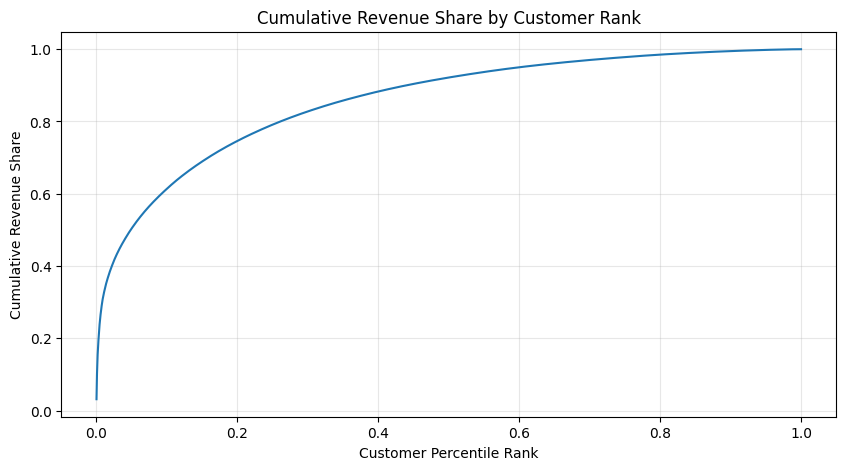

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(
    customer_metrics_sorted["customer_percentile_rank"],
    customer_metrics_sorted["cumulative_revenue_share"],
)
plt.title("Cumulative Revenue Share by Customer Rank")
plt.xlabel("Customer Percentile Rank")
plt.ylabel("Cumulative Revenue Share")
plt.grid(True, alpha=0.3)
plt.show()

## 9. New vs Returning Customers by Month

This section analyzes how the customer base changes over time.

- **New customer** — customer whose first purchase happened in the current month.
- **Returning customer** — customer who made a purchase in the current month but had their first purchase before this month.

This helps evaluate whether monthly sales are driven by acquisition or by existing customers.

In [21]:
first_purchase = (
    orders
    .groupby("customer_id", as_index=False)
    .agg(first_purchase_date=("invoice_date", "min"))
)

first_purchase["first_purchase_month"] = (
    first_purchase["first_purchase_date"].dt.to_period("M").astype(str)
)

orders_with_first = orders.merge(first_purchase, on="customer_id", how="left")

orders_with_first["customer_type_monthly"] = np.where(
    orders_with_first["invoice_month"] == orders_with_first["first_purchase_month"],
    "New customer",
    "Returning customer",
)

monthly_customer_type = (
    orders_with_first
    .groupby(["invoice_month", "customer_type_monthly"], as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        orders=("invoice_no", "nunique"),
        revenue=("order_revenue", "sum"),
    )
)

monthly_customer_type.head()

,invoice_month,customer_type_monthly,customers,orders,revenue
0,2010-12,New customer,885,1400,"572,713.89"
1,2011-01,New customer,417,470,"293,207.35"
2,2011-01,Returning customer,324,517,"276,237.69"
3,2011-02,New customer,380,422,"158,142.07"
4,2011-02,Returning customer,378,575,"288,995.28"


In [22]:
monthly_customer_pivot = (
    monthly_customer_type
    .pivot_table(
        index="invoice_month",
        columns="customer_type_monthly",
        values="customers",
        fill_value=0,
    )
    .reset_index()
)

monthly_customer_pivot

customer_type_monthly,invoice_month,New customer,Returning customer
0,2010-12,885.00,0.00
1,2011-01,417.00,324.00
2,2011-02,380.00,378.00
3,2011-03,452.00,522.00
4,2011-04,300.00,556.00
5,2011-05,284.00,772.00
6,2011-06,242.00,749.00
7,2011-07,188.00,761.00
8,2011-08,169.00,766.00
9,2011-09,299.00,967.00


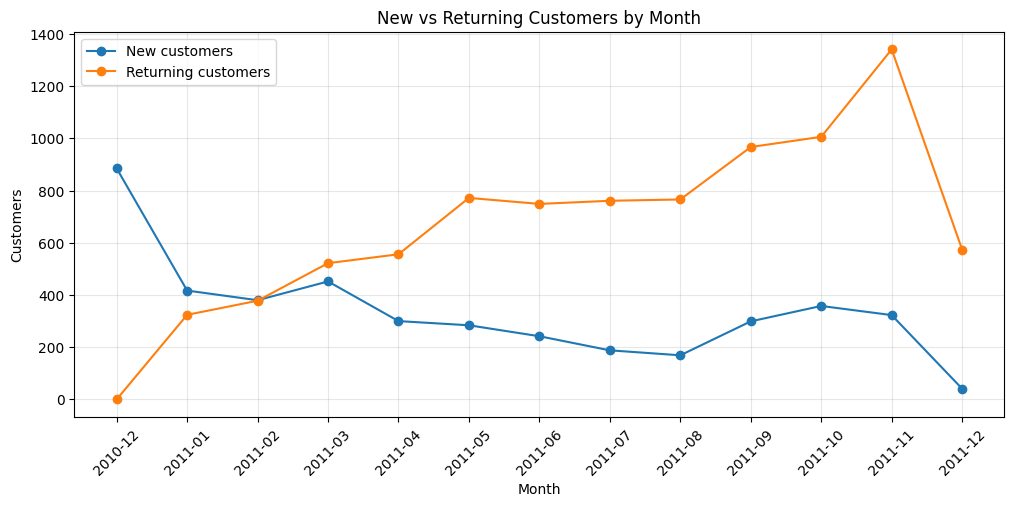

In [23]:
plt.figure(figsize=(12, 5))

if "New customer" in monthly_customer_pivot.columns:
    plt.plot(
        monthly_customer_pivot["invoice_month"],
        monthly_customer_pivot["New customer"],
        marker="o",
        label="New customers",
    )

if "Returning customer" in monthly_customer_pivot.columns:
    plt.plot(
        monthly_customer_pivot["invoice_month"],
        monthly_customer_pivot["Returning customer"],
        marker="o",
        label="Returning customers",
    )

plt.title("New vs Returning Customers by Month")
plt.xlabel("Month")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Note about December 2011

The dataset ends on 2011-12-09, so December 2011 is an incomplete month.  
It should not be directly compared with full months when analyzing customer acquisition or returning customer volume.

## 10. Monthly Revenue from New vs Returning Customers

In [24]:
monthly_revenue_pivot = (
    monthly_customer_type
    .pivot_table(
        index="invoice_month",
        columns="customer_type_monthly",
        values="revenue",
        fill_value=0,
    )
    .reset_index()
)

monthly_revenue_pivot

customer_type_monthly,invoice_month,New customer,Returning customer
0,2010-12,"572,713.89",0.00
1,2011-01,"293,207.35","276,237.69"
2,2011-02,"158,142.07","288,995.28"
3,2011-03,"200,069.96","395,430.80"
4,2011-04,"122,011.49","347,188.87"
5,2011-05,"124,103.78","554,490.78"
6,2011-06,"135,742.95","525,470.74"
7,2011-07,"74,008.75","526,082.26"
8,2011-08,"79,756.10","565,587.80"
9,2011-09,"155,103.90","797,734.48"


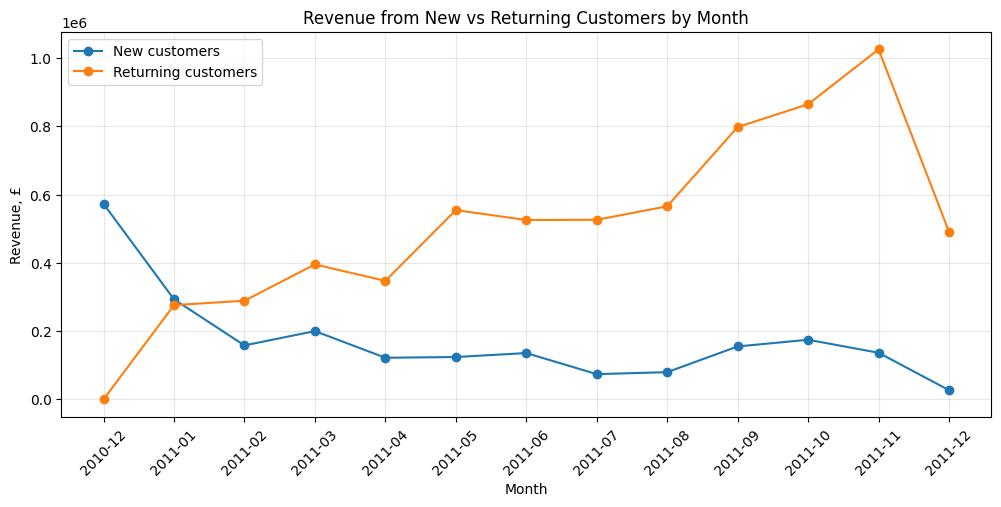

In [25]:
plt.figure(figsize=(12, 5))

if "New customer" in monthly_revenue_pivot.columns:
    plt.plot(
        monthly_revenue_pivot["invoice_month"],
        monthly_revenue_pivot["New customer"],
        marker="o",
        label="New customers",
    )

if "Returning customer" in monthly_revenue_pivot.columns:
    plt.plot(
        monthly_revenue_pivot["invoice_month"],
        monthly_revenue_pivot["Returning customer"],
        marker="o",
        label="Returning customers",
    )

plt.title("Revenue from New vs Returning Customers by Month")
plt.xlabel("Month")
plt.ylabel("Revenue, £")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Customer Lifetime

In [26]:
customer_metrics["customer_lifetime_days"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count   4,338.00
mean      130.45
std       132.04
min         0.00
25%         0.00
50%        92.50
75%       251.75
90%       339.00
95%       356.00
99%       367.00
max       373.00
Name: customer_lifetime_days, dtype: float64

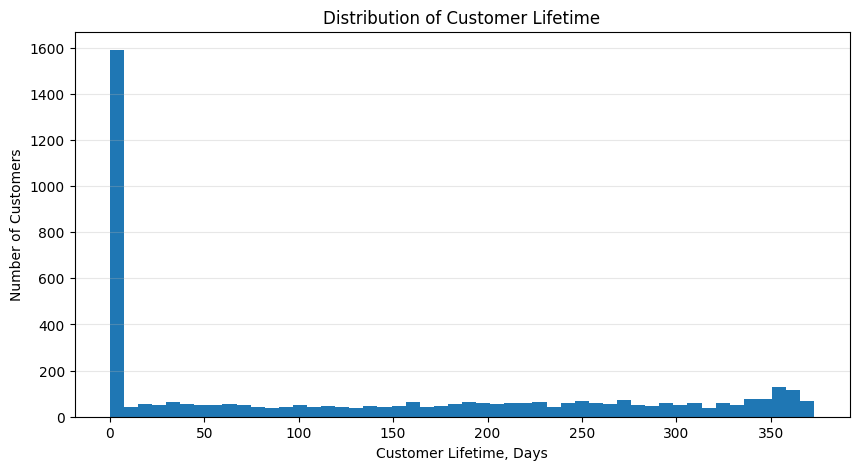

In [27]:
plt.figure(figsize=(10, 5))
plt.hist(customer_metrics["customer_lifetime_days"], bins=50)
plt.title("Distribution of Customer Lifetime")
plt.xlabel("Customer Lifetime, Days")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.show()

Customers with lifetime equal to zero may include one-time customers or customers who made multiple orders on the same day.

## 12. Save Customer-Level Outputs

The customer-level datasets will be used later for RFM segmentation and dashboarding.

In [28]:
output_dir = ROOT_DIR / "data" / "processed"

customer_metrics.to_csv(output_dir / "customer_metrics.csv", index=False)
customer_type_summary.to_csv(output_dir / "customer_type_summary.csv", index=False)
monthly_customer_type.to_csv(output_dir / "monthly_customer_type.csv", index=False)
concentration.to_csv(output_dir / "customer_revenue_concentration.csv", index=False)

print("Saved files:")
print(output_dir / "customer_metrics.csv")
print(output_dir / "customer_type_summary.csv")
print(output_dir / "monthly_customer_type.csv")
print(output_dir / "customer_revenue_concentration.csv")

Saved files:
D:\pychramProjects\E-commerce-Analytics\data\processed\customer_metrics.csv
D:\pychramProjects\E-commerce-Analytics\data\processed\customer_type_summary.csv
D:\pychramProjects\E-commerce-Analytics\data\processed\monthly_customer_type.csv
D:\pychramProjects\E-commerce-Analytics\data\processed\customer_revenue_concentration.csv


# Findings

The customer analysis shows that the business is strongly driven by repeat customers and a relatively small group of high-value buyers.

1. The cleaned dataset contains **4,338 customers** and **18,532 orders**.
2. **2,845 customers** made more than one order. This means the repeat purchase rate is approximately **66%**.
3. Repeat customers represent **66% of the customer base**, but generate about **93% of total revenue**.
4. One-time customers represent **34% of customers**, but generate only about **7% of revenue**.
5. The average revenue per repeat customer is **£2,915.68**, while the average revenue per one-time customer is only **£412.80**.
6. Customer revenue is highly concentrated:
   - **Top 1%** of customers generate about **32%** of total revenue.
   - **Top 5%** generate about **50%** of total revenue.
   - **Top 10%** generate about **61%** of total revenue.
   - **Top 20%** generate about **75%** of total revenue.
7. The highest-value customer is **Customer 14646**, who generated **£280,206.02** across **73 orders**.
8. Returning customers become the main revenue source after the first months of observation. In **November 2011**, returning customers generated over **£1.0M**, while new customers generated about **£136.6K**.
9. December 2011 should be interpreted carefully because the dataset ends on **2011-12-09**, so this month is incomplete.
10. The median customer lifetime is **92.5 days**, while the average is **130.45 days**, which suggests that some long-term customers significantly increase the average.